In [ ]:
import pandas as pd

# Load the fixed-width file
df = pd.read_fwf(r"C:\Users\salma\OneDrive\Desktop\New folder\blitz_rating_list\blitz_rating_list.txt", skipfooter=0)

# Display the result
print(df)

        ID Number                   Name  Fed Sex  Tit WTit OTit  FOA  FEB26  \
0        40129322                9147028  NED   M  NaN  NaN  NaN  NaN   1530   
1       537001345   A Arbhin Vanniarajan  IND   M  NaN  NaN  NaN  NaN   1472   
2        10245154  A B M Jobair, Hossain  BAN   M  NaN  NaN  NaN  NaN   1748   
3       537070436              A Darshil  IND   M  NaN  NaN  NaN  NaN   1459   
4        10207538       A E M, Doshtagir  BAN   M  NaN  NaN  NaN  NaN   1916   
...           ...                    ...  ...  ..  ...  ...  ...  ...    ...   
289330   55755011        Zyuzina, Marina  RUS   F  NaN  NaN  NaN  NaN   1557   
289331   21054274        Zywczak, Damian  POL   M  NaN  NaN  NaN  NaN   1632   
289332    1189980         Zywert, Kacper  POL   M  NaN  NaN  NaN  NaN   1765   
289333   41818385       Zyzanski, Michal  POL   M  NaN  NaN  NaN  NaN   1421   
289334  545028842        Zyznowski, Adam  POL   M  NaN  NaN  NaN  NaN   1483   

        Gms   K  B-day Flag  
0        

In [3]:
len(df)

289335

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.colors as mcolors
import numpy as np
from scipy.interpolate import griddata

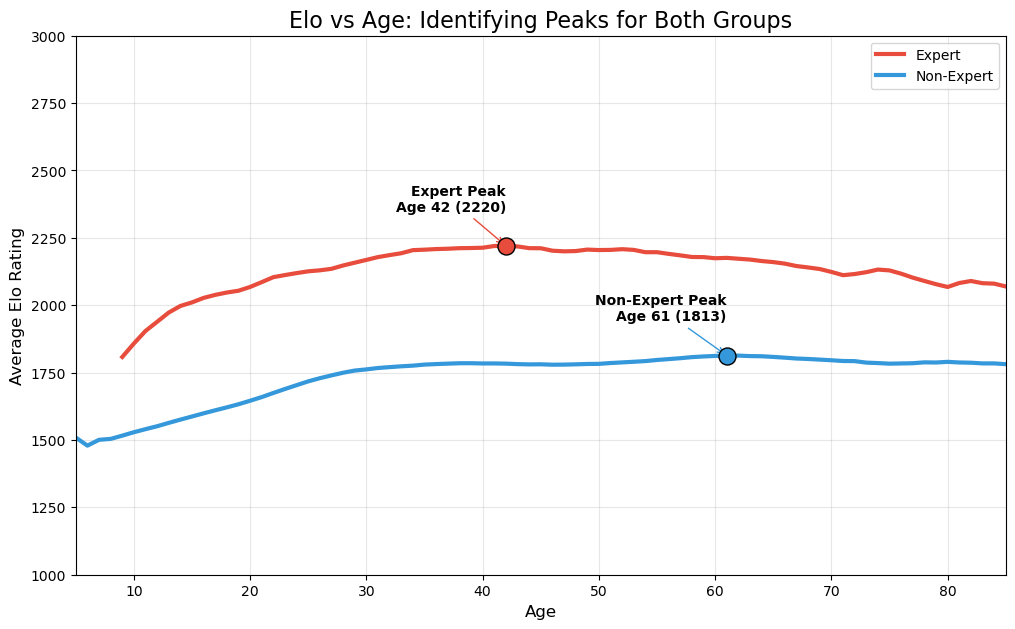

In [10]:
# 1. Preparation
df['Age'] = 2026 - df['B-day']
df['Category'] = df['Tit'].apply(lambda x: 'Expert' if pd.notnull(x) and x != '' else 'Non-Expert')

# 2. Grouping
trend = df.groupby(['Category', 'Age'])['FEB26'].mean().reset_index()

plt.figure(figsize=(12, 7))
colors = {'Expert': '#e74c3c', 'Non-Expert': '#3498db'}

for cat in ['Expert', 'Non-Expert']:
    subset = trend[trend['Category'] == cat].sort_values('Age')
    
    # 3. Smoothing (Crucial for finding a clean peak)
    subset['Smoothed'] = subset['FEB26'].rolling(window=5, center=True).mean().fillna(subset['FEB26'])
    
    # Plot the main line
    plt.plot(subset['Age'], subset['Smoothed'], label=cat, color=colors[cat], linewidth=3)
    
    # 4. Finding the Peak within a "Competitive Window" (Ages 15-65)
    # This ignores the 'noise' from very young or very old players
    peak_window = subset[(subset['Age'] >= 15) & (subset['Age'] <= 65)]
    
    if not peak_window.empty:
        peak_idx = peak_window['Smoothed'].idxmax()
        peak_age = peak_window.loc[peak_idx, 'Age']
        peak_elo = peak_window.loc[peak_idx, 'Smoothed']
        
        # 5. Adding the Markers
        plt.scatter(peak_age, peak_elo, color=colors[cat], s=150, edgecolors='black', zorder=5)
        plt.annotate(f'{cat} Peak\nAge {int(peak_age)} ({int(peak_elo)})', 
                     xy=(peak_age, peak_elo), 
                     xytext=(0, 25), 
                     textcoords='offset points',
                     ha='right', fontsize=10, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color=colors[cat]))

# Final touches
plt.title('Elo vs Age: Identifying Peaks for Both Groups', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Elo Rating', fontsize=12)
plt.ylim(1000,3000)
plt.xlim(5, 85)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

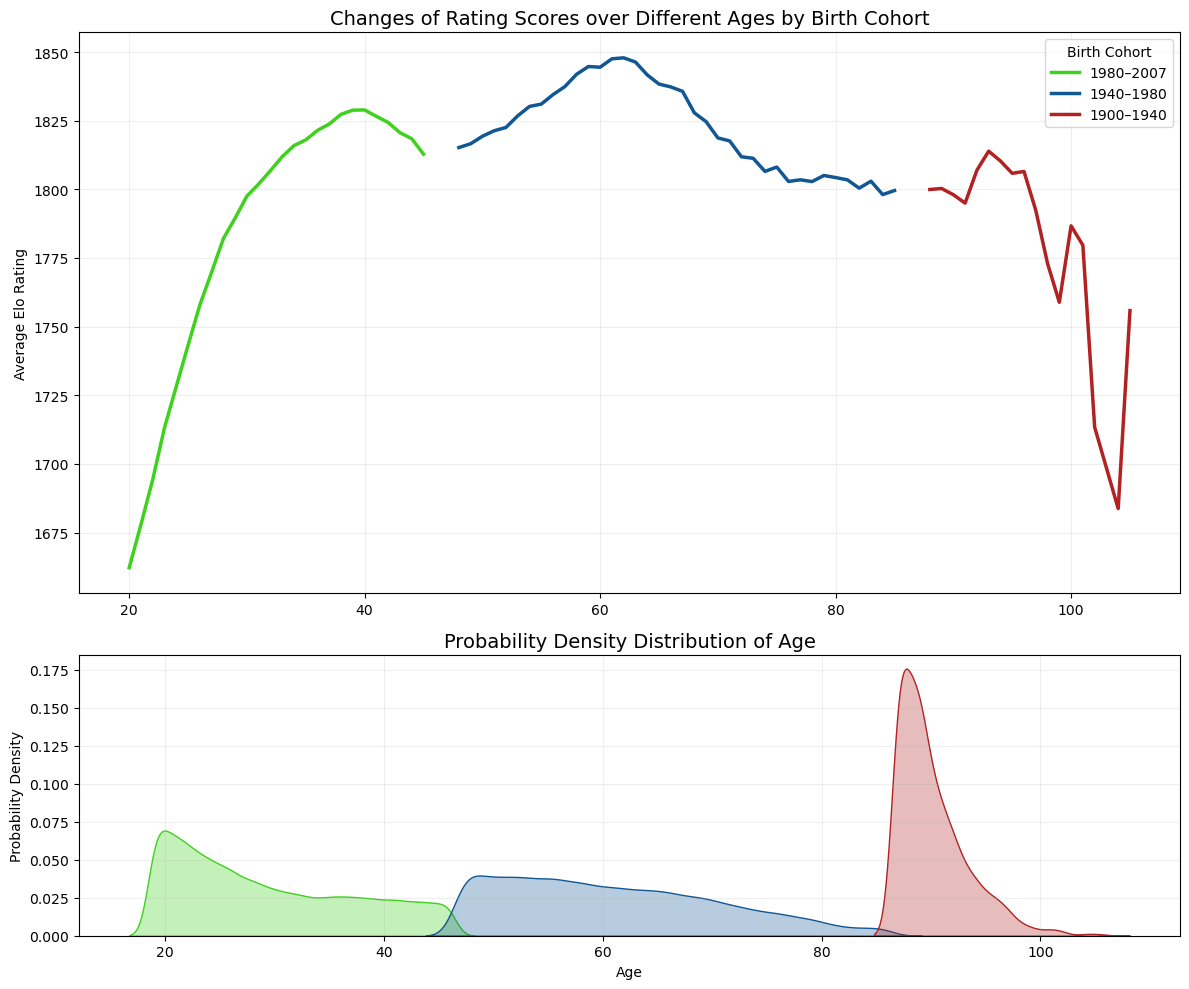

In [15]:
# 1. Define the Birth Cohorts based on your criteria
def categorize_cohort(year):
    if 1980 <= year <= 2007:
        return '1980–2007'
    elif 1940 <= year < 1980:
        return '1940–1980'
    elif 1900 <= year < 1940:
        return '1900–1940'
    else:
        return 'Other'

df['Cohort'] = df['B-day'].apply(categorize_cohort)
df['Age'] = 2026 - df['B-day']

# Filter out 'Other' for the specific comparison
df_filtered = df[df['Cohort'] != 'Other']

# 2. Set up the figure with two subplots (Top for Ratings, Bottom for Density)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})
palette = {'1980–2007': "#3ED11D", '1940–1980': "#115794", '1900–1940': "#B22222"}

# --- UPPER GRAPH: Rating Scores over Age ---
for cohort, color in palette.items():
    subset = df_filtered[df_filtered['Cohort'] == cohort]
    # Group by age and smooth the average Elo
    trend = subset.groupby('Age')['FEB26'].mean().rolling(window=3, center=True).mean()
    ax1.plot(trend.index, trend.values, label=cohort, color=color, linewidth=2.5)

ax1.set_title('Changes of Rating Scores over Different Ages by Birth Cohort', fontsize=14)
ax1.set_ylabel('Average Elo Rating')
ax1.legend(title="Birth Cohort")
ax1.grid(True, alpha=0.2)

# --- LOWER GRAPH: Probability Density Distribution ---
for cohort, color in palette.items():
    sns.kdeplot(data=df_filtered[df_filtered['Cohort'] == cohort], x='Age', 
                ax=ax2, color=color, fill=True, label=cohort, alpha=0.3)

ax2.set_title('Probability Density Distribution of Age', fontsize=14)
ax2.set_xlabel('Age')
ax2.set_ylabel('Probability Density')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                  FEB26   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     5350.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:17:04   Log-Likelihood:            -1.3977e+06
No. Observations:              207313   AIC:                         2.795e+06
Df Residuals:                  207309   BIC:                         2.795e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1851.4254    

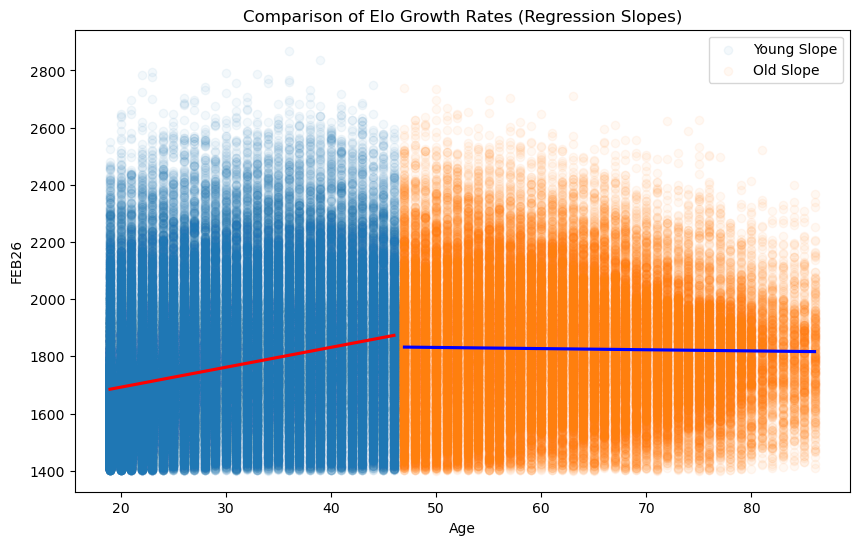

In [17]:
# 1. Prepare the two groups
def categorize(year):
    if 1980 <= year <= 2007: return 'Young'
    if 1940 <= year < 1980: return 'Old'
    return None

df['Cohort'] = df['B-day'].apply(categorize)
# Drop players not in these two specific groups for the regression
df_reg = df.dropna(subset=['Cohort']).copy()

# 2. Run the Regression Model
# The 'Age * Cohort' syntax automatically includes both main effects and the interaction
model = smf.ols(formula="FEB26 ~ Age * Cohort", data=df_reg).fit()

print(model.summary())

# 3. Visualize the Regression Slopes
plt.figure(figsize=(10, 6))
sns.regplot(data=df_reg[df_reg['Cohort']=='Young'], x='Age', y='FEB26', 
            scatter_kws={'alpha':0.05}, line_kws={'color':'red'}, label='Young Slope')
sns.regplot(data=df_reg[df_reg['Cohort']=='Old'], x='Age', y='FEB26', 
            scatter_kws={'alpha':0.05}, line_kws={'color':'blue'}, label='Old Slope')

plt.title('Comparison of Elo Growth Rates (Regression Slopes)')
plt.legend()
plt.show()

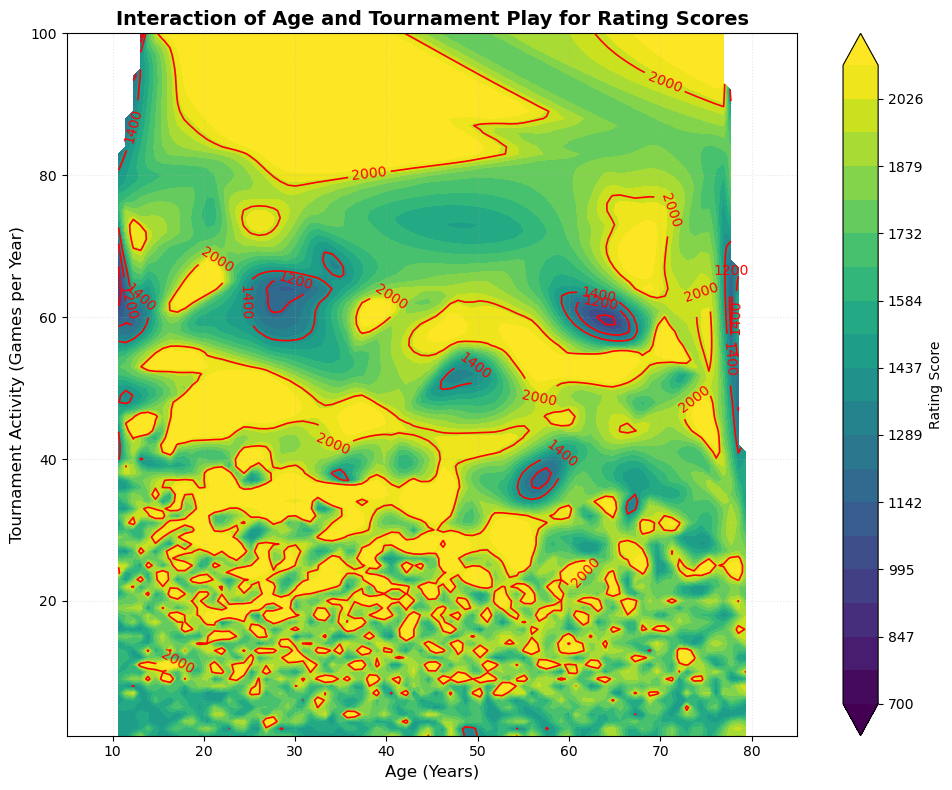

In [45]:
from scipy.interpolate import griddata

# 1. Prepare the coordinate ranges
# Age (X-axis) from 5 to 85, Tournament Activity (Y-axis) from 1 to 100
age_axis = np.linspace(5, 85, 100)
games_axis = np.linspace(1, 100, 100)

# 2. Create the Grid using meshgrid
# X and Y will be 100x100 matrices representing every point on the map
X, Y = np.meshgrid(age_axis, games_axis)

# 3. Interpolate the Z values (Ratings) onto the Meshgrid
# We map your existing (Age, Gms, FEB26) data onto the (X, Y) grid
Z = griddata((df['Age'], df['Gms']), df['FEB26'], (X, Y), method='cubic')

# 4. Generate the Plot
plt.figure(figsize=(10, 8))

# Filled Contour: 'magma' goes from Black/Purple (~700) to Yellow/White (~2100)
# 'levels' defines the smooth transitions between color bands
cp = plt.contourf(X, Y, Z, levels=np.linspace(700, 2100, 20), cmap='viridis', extend='both')

# Red Contour Lines: Showing areas where rating is constant
cl = plt.contour(X, Y, Z, levels=[1000, 1200, 1400, 2000], 
                 colors='red', linewidths=1.2)

# Label the red lines with their specific rating values
plt.clabel(cl, inline=True, fontsize=10, fmt='%d', colors='red')

# Final Polish
plt.title('Interaction of Age and Tournament Play for Rating Scores', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Tournament Activity (Games per Year)', fontsize=12)
plt.colorbar(cp, label='Rating Score')
plt.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()
